# Football Manager 2023 Exploratory Data Analysis
---

**Objective:** Conduct a thorough exploration of the Football Manager 2023 player dataset to understand its structure, quality, and key patterns, laying the foundation for all downstream analyses.

**Key questions this notebook answers:**
1. What does the data look like and where are the quality issues?
2. How are players distributed across positions, leagues, and nationalities?
3. What do attribute distributions look like, and do they differ by position?
4. Which attributes correlate most strongly with transfer value?
5. Are there early signals of undervalued players and hidden wonderkids?

## Environment setup

In [1]:
from unittest.mock import inplace

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
import seaborn as sns
import os

from IPython.core.pylabtools import figsize
from pandas.core.common import random_state

In [2]:
# create output directories for data and visuals
os.makedirs("data", exist_ok=True)
os.makedirs("visuals", exist_ok=True)

In [3]:
# setting up design styles for plots
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d2e',
    'axes.edgecolor': '#2e3250',
    'axes.labelcolor': '#c9d1d9',
    'axes.titlecolor': '#ffffff',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',
    'grid.color': '#2e3250',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'legend.facecolor': '#1a1d2e',
    'legend.edgecolor': '#2e3250',
    'legend.labelcolor': '#c9d1d9',
    'font.family': 'DejaVu Sans',
})

FM_GREEN  = '#00d4aa'
FM_BLUE   = '#4f9eff'
FM_ORANGE = '#ff8c42'
FM_RED    = '#ff4757'
FM_PURPLE = '#a29bfe'
FM_YELLOW = '#ffd32a'

PALETTE = [FM_GREEN, FM_BLUE, FM_ORANGE, FM_RED, FM_PURPLE, FM_YELLOW, '#fd79a8', '#55efc4', '#74b9ff', '#fdcb6e']

In [4]:
# downloading dataset from kaggle
path = kagglehub.dataset_download("siddhrajthakor/football-manager-2023-dataset")

# loading the merged dataset
csv_path = os.path.join(path, "merged_players (1).csv")
raw_dataframe = pd.read_csv(csv_path, encoding="utf-8", low_memory=False)

## Exploring data structure and schema

In [5]:
# lookup of data
raw_dataframe.head(200)

,Unnamed: 0,UID,Name,Rec,DOB,Inf,Club,Based,Nat,Height,...,Pres,Loy,Inj Pr,Imp M,Dirt,Amb,Ada,Cons,Cont,Media Handling
0,0,2002078863,Scott King,- - -,10/9/2004 (17 years old),Ama,Colorado International,U.S.A. (Mountain Division),USA,"5'9""",...,14,9,11,10,15,11,7,14,11,Media-friendly
1,1,2002078833,José González,- - -,23/10/2004 (17 years old),Ctr,NC Fusion U23,U.S.A. (South Atlantic Division),USA,"5'4""",...,14,9,3,12,14,11,6,9,8,Media-friendly
2,2,2002078815,Chase Crane,- - -,6/12/2004 (17 years old),Ctr,NC Fusion U23,U.S.A. (South Atlantic Division),USA,"6'2""",...,9,11,2,8,15,13,10,8,9,Level-headed
3,3,2002078813,Emmanuel Araiza,- - -,30/11/2004 (17 years old),Ctr,Oly Town FC,U.S.A. (Northwest Division),USA,"6'1""",...,12,10,4,13,12,10,13,10,10,Media-friendly
4,4,2002078799,Yang Xiaofeng,- - -,30/6/2004 (17 years old),Ctr,Oly Town FC,U.S.A. (Northwest Division),CHN,"6'0""",...,9,11,14,7,7,6,11,7,5,Level-headed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,195,2002078604,Jim Daniels-Lancaster,- - -,9/9/2006 (15 years old),Ctr,RISE SC,U.S.A. (Frontier Division),USA,"6'0""",...,5,17,12,7,11,5,9,9,5,Media-friendly
196,196,2002078603,Kevin Hernández,- - -,15/8/2006 (15 years old),Ctr,RISE SC,U.S.A. (Frontier Division),USA,"5'6""",...,10,9,9,13,7,10,7,7,11,"Volatile, Media-friendly, Confrontational"
197,197,2002078602,Jeffrey Landa,- - -,2/9/2006 (15 years old),Ctr,RISE SC,U.S.A. (Frontier Division),USA,"5'7""",...,12,11,7,12,8,13,10,6,8,Level-headed
198,198,2002078601,Carlos Márquez,- - -,30/3/2005 (17 years old),Ctr,RISE SC,U.S.A. (Frontier Division),USA,"5'11""",...,6,11,12,4,7,11,7,14,15,Outspoken


In [6]:
# check the number of rows and columns
print(f"Number of rows: {raw_dataframe.shape[0]:,}")
print(f"Number of columns: {raw_dataframe.shape[1]}")

Number of rows: 91,672
Number of columns: 88


In [7]:
# check each column and their title
for i, col in enumerate(raw_dataframe.columns, 1):
    print(f"{i:>3}. {col}")

  1. Unnamed: 0
  2. UID
  3. Name
  4. Rec
  5. DOB
  6. Inf
  7. Club
  8. Based
  9. Nat
 10. Height
 11. Weight
 12. Age
 13. Position
 14. Transfer Value
 15. Media Description
 16. Rc Injury
 17. Preferred Foot
 18. Left Foot
 19. Right Foot
 20. Caps
 21. AT Apps
 22. AT Gls
 23. AT Lge Apps
 24. AT Lge Gls
 25. Team
 26. Yth Apps
 27. Yth Gls
 28. Acc
 29. Wor
 30. Vis
 31. Thr
 32. Tec
 33. Tea
 34. Tck
 35. Str
 36. Sta
 37. TRO
 38. Ref
 39. Pun
 40. Pos
 41. Pen
 42. Pas
 43. Pac
 44. 1v1
 45. OtB
 46. Nat.1
 47. Mar
 48. L Th
 49. Lon
 50. Ldr
 51. Kic
 52. Jum
 53. Hea
 54. Han
 55. Fre
 56. Fla
 57. Fir
 58. Fin
 59. Ecc
 60. Dri
 61. Det
 62. Dec
 63. Cro
 64. Cor
 65. Cnt
 66. Cmp
 67. Com
 68. Cmd
 69. Bra
 70. Bal
 71. Ant
 72. Agi
 73. Agg
 74. Aer
 75. Vers
 76. Temp
 77. Spor
 78. Prof
 79. Pres
 80. Loy
 81. Inj Pr
 82. Imp M
 83. Dirt
 84. Amb
 85. Ada
 86. Cons
 87. Cont
 88. Media Handling


In [8]:
# get the overview of the datatypes of the columns
datatype_summary = raw_dataframe.dtypes.value_counts().reset_index()

datatype_summary.columns = ['dtype', 'count']

print(datatype_summary.to_string(index=False))

dtype  count
int64     64
  str     24


In [9]:
# sample some rows and key columns
key_columns = ["Name", "Age", "Nat", "Club", "Position", "Transfer Value"]

available = [column for column in key_columns if column in raw_dataframe.columns]

raw_dataframe[available].head(10)

,Name,Age,Nat,Club,Position,Transfer Value
0,Scott King,17,USA,Colorado International,AM (R),0$
1,José González,17,USA,NC Fusion U23,M (C),0$
2,Chase Crane,17,USA,NC Fusion U23,GK,0$
3,Emmanuel Araiza,17,USA,Oly Town FC,D (C),0$
4,Yang Xiaofeng,17,CHN,Oly Town FC,D (LC),0$
5,Arman Hovhannisyan,16,USA,Sacramento United,AM (C),0$
6,Abdul Bangura,15,USA,Sacramento United,M (L),0$
7,Kevin López,15,GUA,Sacramento United,M (C),0$
8,Patrick Bryan,17,USA,Sacramento United,ST (C),0$
9,Adam Green,15,USA,Sacramento United,ST (C),0$


## Assessing data quality

In [10]:
# replacing '-' with 'NaN' across the whole dataframe
dataframe = raw_dataframe.copy()

dataframe.replace('-', np.nan, inplace=True)
dataframe.replace('', np.nan, inplace=True)
dataframe.replace("- - -", np.nan, inplace=True)

dataframe.head(10)

,Unnamed: 0,UID,Name,Rec,DOB,Inf,Club,Based,Nat,Height,...,Pres,Loy,Inj Pr,Imp M,Dirt,Amb,Ada,Cons,Cont,Media Handling
0,0,2002078863,Scott King,NaN,10/9/2004 (17 years old),Ama,Colorado International,U.S.A. (Mountain Division),USA,"5'9""",...,14,9,11,10,15,11,7,14,11,Media-friendly
1,1,2002078833,José González,NaN,23/10/2004 (17 years old),Ctr,NC Fusion U23,U.S.A. (South Atlantic Division),USA,"5'4""",...,14,9,3,12,14,11,6,9,8,Media-friendly
2,2,2002078815,Chase Crane,NaN,6/12/2004 (17 years old),Ctr,NC Fusion U23,U.S.A. (South Atlantic Division),USA,"6'2""",...,9,11,2,8,15,13,10,8,9,Level-headed
3,3,2002078813,Emmanuel Araiza,NaN,30/11/2004 (17 years old),Ctr,Oly Town FC,U.S.A. (Northwest Division),USA,"6'1""",...,12,10,4,13,12,10,13,10,10,Media-friendly
4,4,2002078799,Yang Xiaofeng,NaN,30/6/2004 (17 years old),Ctr,Oly Town FC,U.S.A. (Northwest Division),CHN,"6'0""",...,9,11,14,7,7,6,11,7,5,Level-headed
5,5,2002078794,Arman Hovhannisyan,NaN,15/12/2005 (16 years old),Ama,Sacramento United,U.S.A. (Southwest Division),USA,"6'0""",...,13,14,10,12,10,14,6,10,7,Level-headed
6,6,2002078793,Abdul Bangura,NaN,6/8/2006 (15 years old),Ama,Sacramento United,U.S.A. (Southwest Division),USA,"5'9""",...,11,10,8,12,15,7,7,10,12,Media-friendly
7,7,2002078792,Kevin López,NaN,1/10/2006 (15 years old),Ama,Sacramento United,U.S.A. (Southwest Division),GUA,"5'9""",...,14,12,13,15,6,4,13,9,14,Media-friendly
8,8,2002078791,Patrick Bryan,NaN,28/1/2005 (17 years old),Ama,Sacramento United,U.S.A. (Southwest Division),USA,"5'10""",...,10,8,10,14,9,10,9,13,8,Media-friendly
9,9,2002078790,Adam Green,NaN,23/8/2006 (15 years old),Ama,Sacramento United,U.S.A. (Southwest Division),USA,"6'0""",...,9,7,13,7,10,15,6,6,8,Media-friendly


In [11]:
# summarizing missing value
missing = dataframe.isnull().sum()
missing_percentage = (missing / len(dataframe) * 100).round(2)
missing_dataframe = pd.DataFrame({"missing_count": missing, "missing_percentage": missing_percentage})
missing_dataframe = missing_dataframe[missing_dataframe["missing_count"] > 0].sort_values("missing_percentage", ascending=False)

print(f"Columns with missing values: {len(missing_dataframe)} / {dataframe.shape[1]}")
print()
print(missing_dataframe.head(20).to_string())

# Note: Players with missing clubs means these players are most likely free agents (11,381 in total)

Columns with missing values: 11 / 88

             missing_count  missing_percentage
Rec                  91672              100.00
Rc Injury            90152               98.34
Yth Gls              88770               96.83
Team                 86134               93.96
Yth Apps             84203               91.85
Inf                  54368               59.31
AT Lge Gls           43392               47.33
AT Gls               43274               47.21
AT Lge Apps          26102               28.47
AT Apps              25820               28.17
Club                 11381               12.41


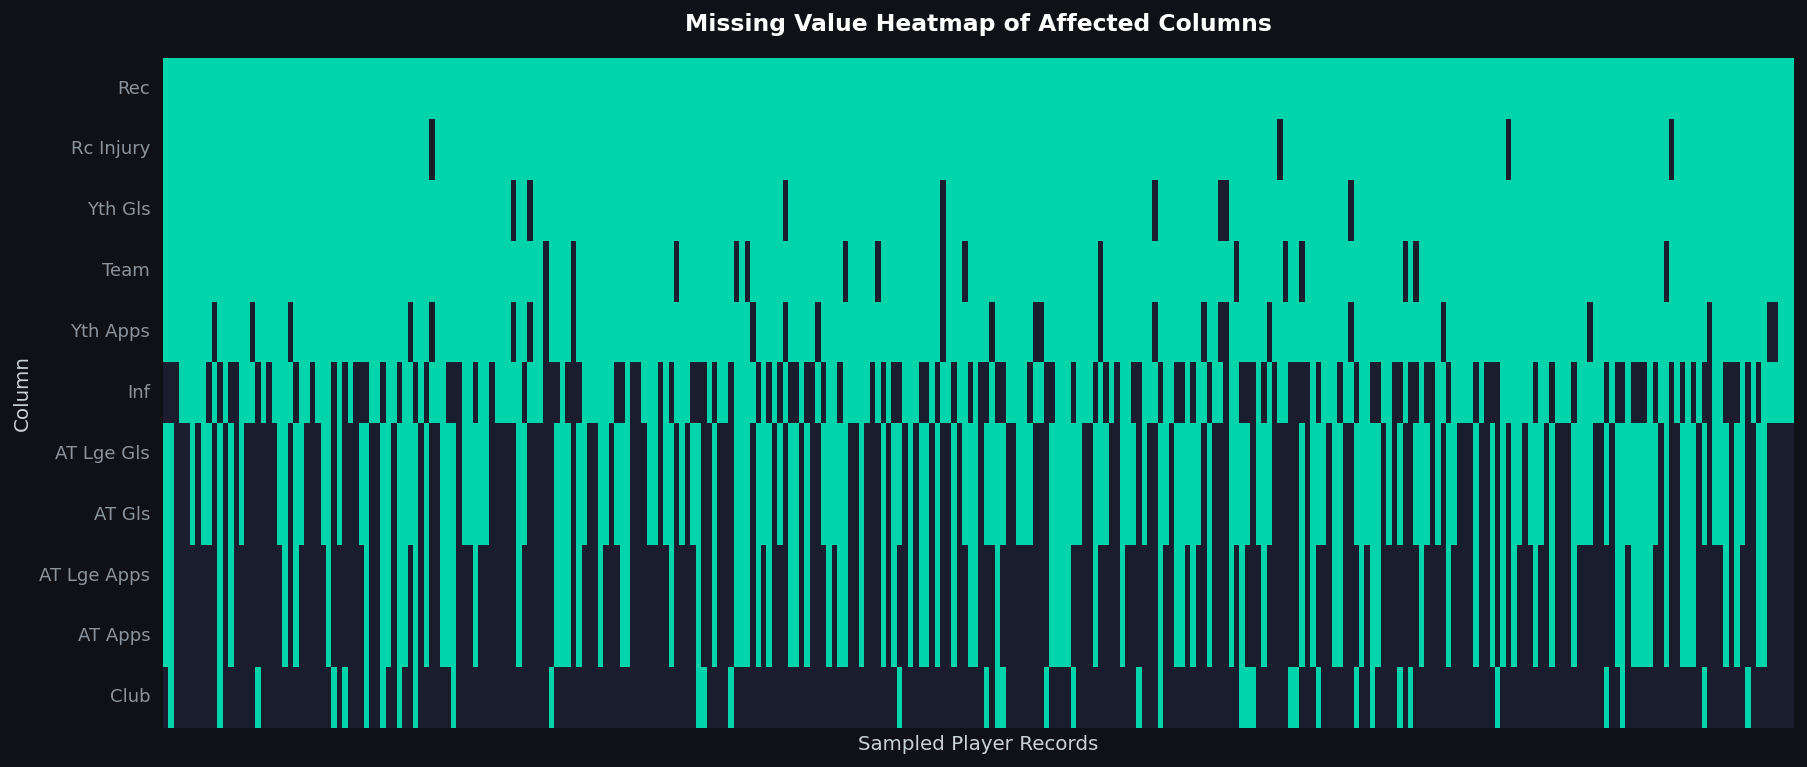

In [12]:
# we had 11 columns with missing values
# showing a heatmap
top_missing_columns = missing_dataframe.head(11).index.tolist()

if top_missing_columns:
    sample = dataframe[top_missing_columns].sample(min(300, len(dataframe)), random_state=42).isnull()

    figure, axis = plt.subplots(figsize=(14, 6))

    sns.heatmap(sample.T, cbar=False, cmap=["#1a1d2e", FM_GREEN], xticklabels=False, ax=axis, linewidths=0)

    axis.set_title("Missing Value Heatmap of Affected Columns", pad=15)
    axis.set_xlabel("Sampled Player Records")
    axis.set_ylabel("Column")

    plt.tight_layout()
    plt.savefig("visuals/missing_heatmap.png", bbox_inches="tight", facecolor="#0f1117")
    plt.show()

In [13]:
# detecting duplicates
total_duplicates = dataframe.duplicated().sum()
uid_duplicates = dataframe.duplicated(subset=["UID"]).sum() if "UID" in dataframe.columns else "N/A"
name_club_duplicates = dataframe.duplicated(subset=["Name", "Club"]).sum() if all(column in dataframe.columns for column in ["Name", "Club"]) else "N/A"

print(f"Number of row duplicates: {total_duplicates:,}")
print(f"Number of UID duplicates: {uid_duplicates:,}")
print(f"Number of Name and Club duplicates: {name_club_duplicates:,}")

Number of row duplicates: 0
Number of UID duplicates: 4,509
Number of Name and Club duplicates: 5,083


In [14]:
# dropping duplicates on UID
if "UID" in dataframe.columns:
    before = len(dataframe)

    dataframe = dataframe.drop_duplicates(subset=["UID"])

    print(f"Rows after duplication cleanup: {len(dataframe):,}")
    print(f"Rows removed: {before - len(dataframe):,}")

Rows after duplication cleanup: 87,163
Rows removed: 4,509


In [15]:
# converting transfer value to numeric
def parse_transfer_value(val):
    if pd.isnull(val):
        return np.nan

    val = str(val).replace('$', '').replace(',', '').strip().upper()

    # when the transfer value is a range
    if '-' in val:
        parts = val.split('-')

        # parsing both sides and returning the average
        low = parse_transfer_value(parts[0])
        high = parse_transfer_value(parts[1])

        return (low + high) / 2 if not (np.isnan(low) or np.isnan(high)) else np.nan

    if 'M' in val.upper():
        return float(val.upper().replace('M', '')) * 1_000_000
    elif 'K' in val.upper():
        return float(val.upper().replace('K', '')) * 1_000
    else:
        try:
            return float(val)
        except:
            return np.nan


if "Transfer Value" in dataframe.columns:
    dataframe["Transfer Value"] = dataframe["Transfer Value"].apply(parse_transfer_value)

    # getting sample after applying parse
    sample = dataframe[dataframe["Transfer Value"] != 0]["Transfer Value"].dropna().sample(10)

    print(sample.to_string(index=False))

357500.0
  8000.0
440000.0
880000.0
 99000.0
 10000.0
235000.0
207500.0
400000.0
357500.0


## Analyzing player data

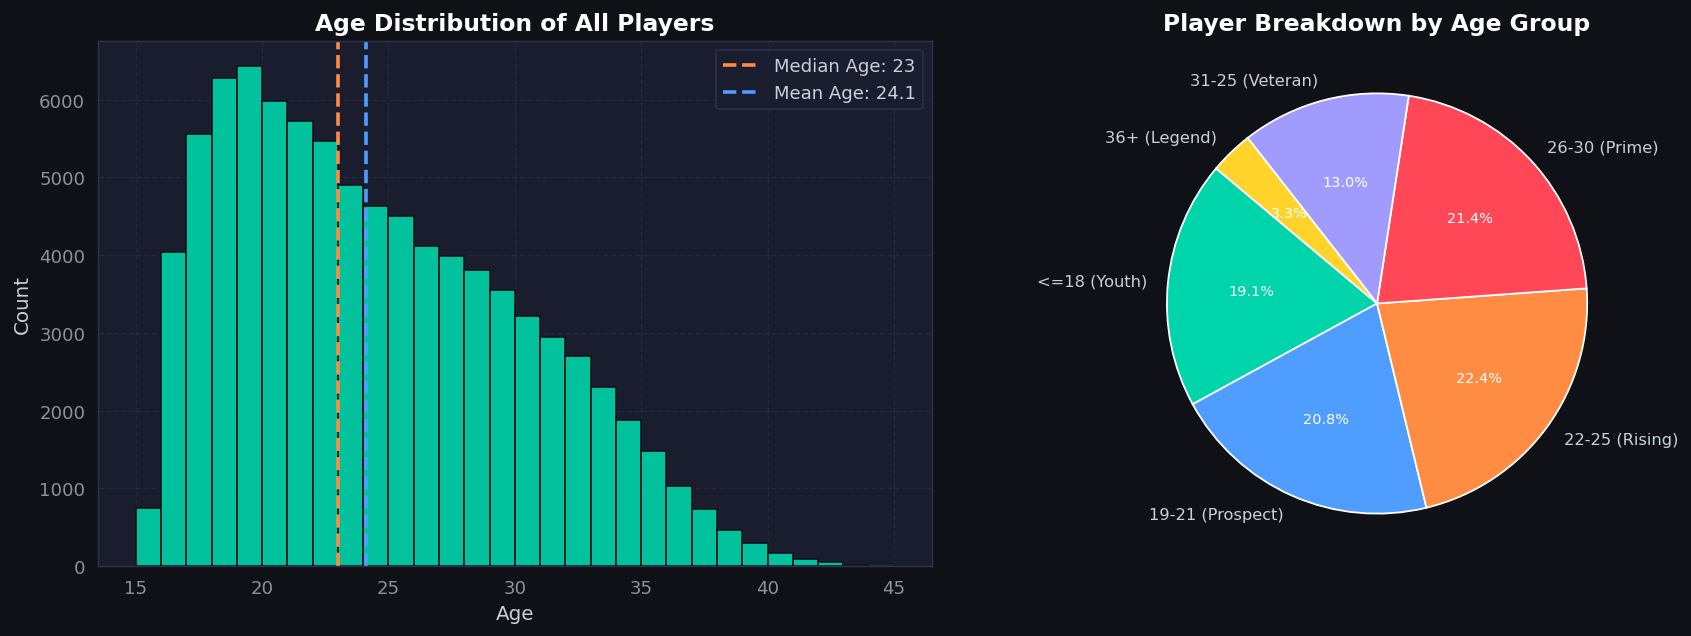

In [16]:
# assessing age distribution of players
figure, axis = plt.subplots(1, 2, figsize=(14, 5))

# using histogram
ax = axis[0]

if "Age" in dataframe.columns:
    ax.hist(dataframe["Age"].dropna(), bins=30, color=FM_GREEN, edgecolor="#0f1117", alpha=0.9)

    ax.axvline(dataframe["Age"].median(), color=FM_ORANGE, linewidth=2, linestyle="--", label=f"Median Age: {dataframe["Age"].median():.0f}")
    ax.axvline(dataframe["Age"].mean(), color=FM_BLUE, linewidth=2, linestyle="--", label=f"Mean Age: {dataframe["Age"].mean():.1f}")

    ax.set_title("Age Distribution of All Players")
    ax.set_xlabel("Age")
    ax.set_ylabel("Count")

    ax.legend()


# using age bracket pie
ax = axis[1]

if "Age" in dataframe.columns:
    bins = [0, 18, 21, 25, 30, 35, 100]
    labels = ["<=18 (Youth)", "19-21 (Prospect)", "22-25 (Rising)", "26-30 (Prime)", "31-25 (Veteran)", "36+ (Legend)"]
    dataframe["Age Group"] = pd.cut(dataframe["Age"], bins=bins, labels=labels)
    age_counts = dataframe["Age Group"].value_counts().sort_index()

    wedges, texts, auto_texts = ax.pie(
        age_counts,
        labels=age_counts.index,
        autopct="%1.1f%%",
        colors=PALETTE[:len(age_counts)],
        startangle=140,
        textprops={"fontsize": 9}
    )

    for text in auto_texts:
        text.set_color("white")
        text.set_fontsize(8)

    ax.set_title("Player Breakdown by Age Group")


plt.tight_layout()
plt.savefig("visuals/age_distribution.png", bbox_inches="tight", facecolor="#0f1117")
plt.show()

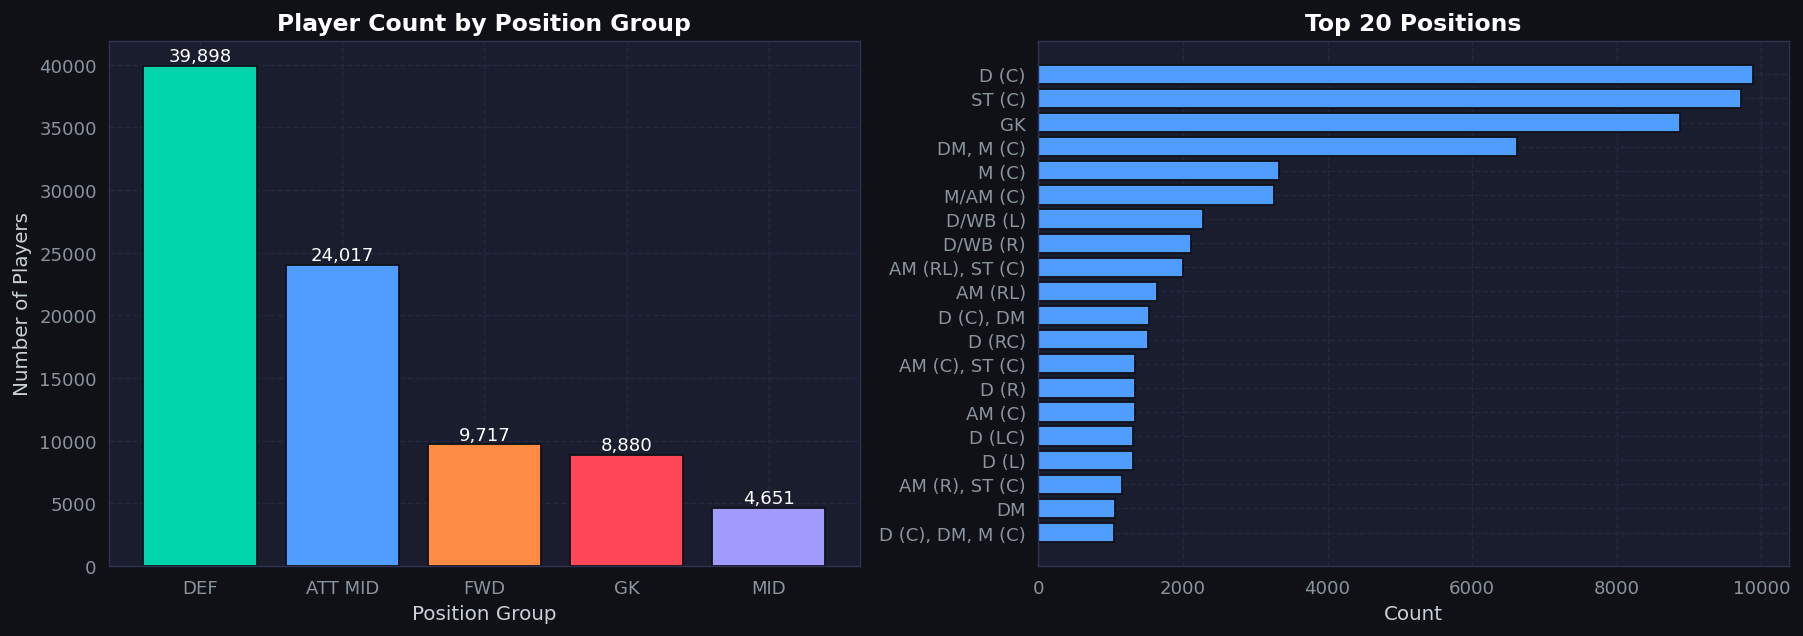

In [17]:
# assessing position distribution
if "Position" in dataframe.columns:
    # standardizing positions into broad groups
    def group_position(pos):
        if pd.isnull(pos):
            return "Unknown"

        pos = str(pos).upper().strip()

        if "GK" in pos:
            return "GK"

        if pos.startswith(("D", "WB")):
            return "DEF"

        elif pos.startswith("DM") or (pos.startswith("M") and "AM" not in pos):
            return "MID"

        elif "AM" in pos:
            return "ATT MID"

        elif "ST" in pos or pos.startswith("S"):
            return "FWD"

        return "Other"


    dataframe["Position Group"] = dataframe["Position"].apply(group_position)

    figure, axis = plt.subplots(1, 2, figsize=(14, 5))

    # using bar for broad groups
    ax = axis[0]
    position_counts = dataframe["Position Group"].value_counts()
    bars = ax.bar(position_counts.index, position_counts.values, color=PALETTE[:len(position_counts)], edgecolor="#0f1117")

    for bar, val in zip(bars, position_counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50, f"{val:,}", ha="center", va="bottom", fontsize=10, color="white")

    ax.set_title("Player Count by Position Group")
    ax.set_xlabel("Position Group")
    ax.set_ylabel("Number of Players")

    # top 20 detailed positions
    ax = axis[1]
    top_positions = dataframe["Position"].value_counts().head(20)

    ax.barh(top_positions.index[::-1], top_positions.values[::-1], color=FM_BLUE, edgecolor="#0f1117")
    ax.set_title("Top 20 Positions")
    ax.set_xlabel("Count")

    plt.tight_layout()
    plt.savefig("visuals/position_distribution.png", bbox_inches="tight", facecolor="#0f1117")
    plt.show()

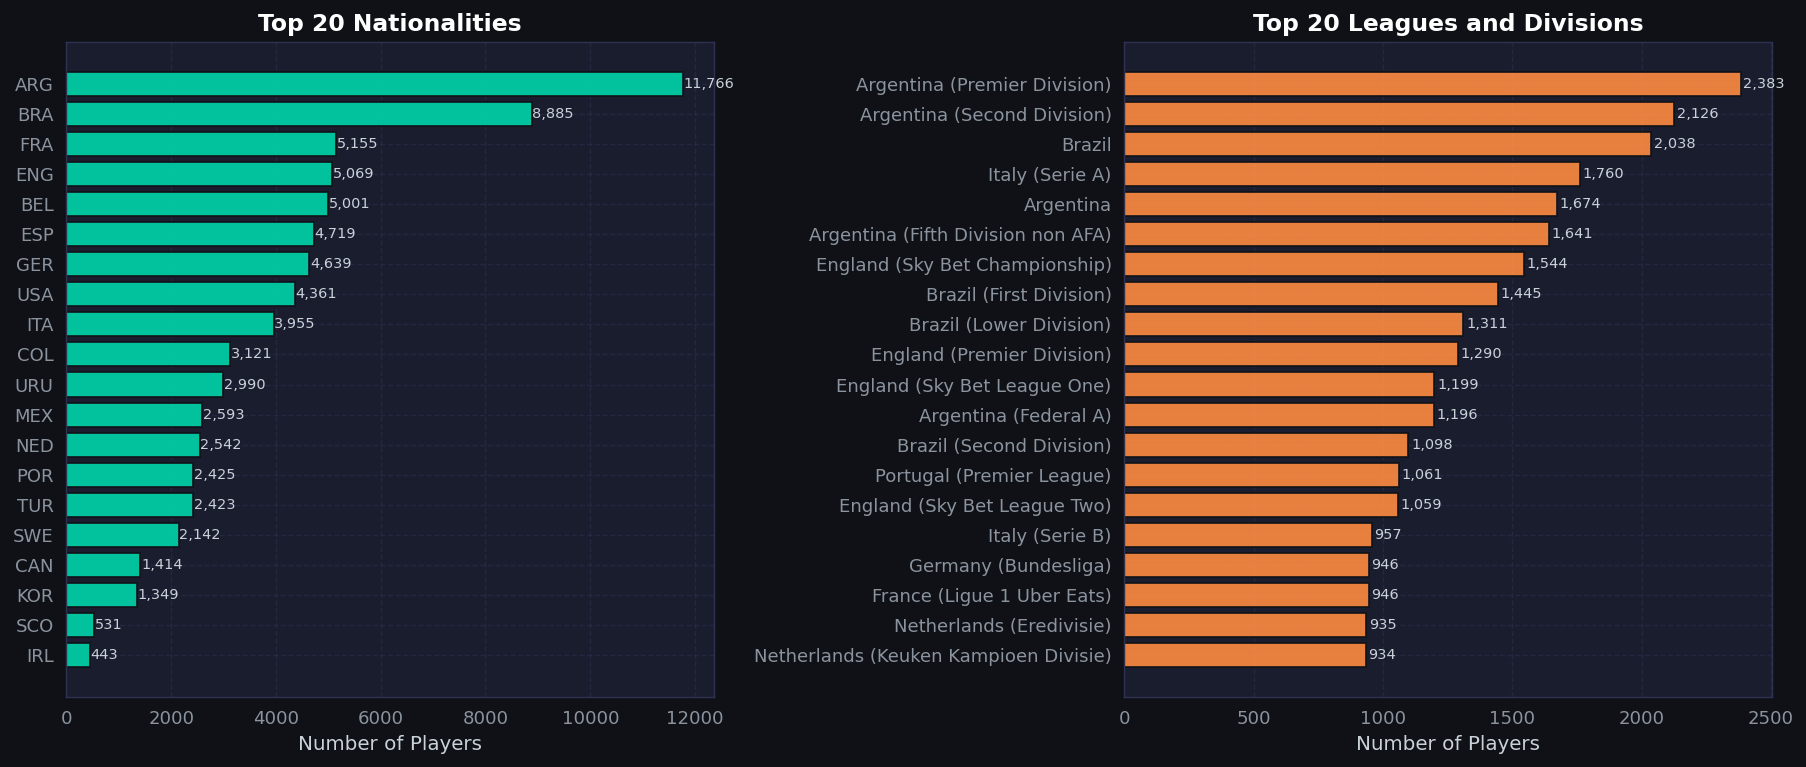

In [18]:
figure, axis = plt.subplots(1, 2, figsize=(14, 6))

if "Nat" in dataframe.columns:
    ax = axis[0]
    top_nations = dataframe["Nat"].value_counts().head(20)
    bars = ax.barh(top_nations.index[::-1], top_nations.values[::-1], color=FM_GREEN, edgecolor="#0f1117", alpha=0.9)

    ax.set_title("Top 20 Nationalities")
    ax.set_xlabel("Number of Players")

    for bar, val in zip(bars, top_nations.values[::-1]):
        ax.text(val + 10, bar.get_y() + bar.get_height() / 2, f"{val:,}", va="center", fontsize=8)


# top leagues and divisions
league_column = "Based" if "Based" in dataframe.columns else ("League" if "League" in dataframe.columns else None)

if league_column:
    ax = axis[1]
    top_leagues = dataframe[league_column].value_counts().head(20)
    bars = ax.barh(top_leagues.index[::-1], top_leagues.values[::-1], color=FM_ORANGE, edgecolor="#0f1117", alpha=0.9)

    ax.set_title("Top 20 Leagues and Divisions")
    ax.set_xlabel("Number of Players")

    for bar, val in zip(bars, top_leagues.values[::-1]):
        ax.text(val + 10, bar.get_y() + bar.get_height() / 2, f"{val:,}", va="center", fontsize=8)


plt.tight_layout()
plt.savefig("visuals/nationality_and_league.png", bbox_inches="tight", facecolor="#0f1117")
plt.show()